In [1]:
import os
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

Config

In [2]:
OUTPUT_DIR = "../Datasets/Split"
TARGET_COL = "TAXA_CRE_INT"          
TEST_SIZE = 0.2
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

Separando em váriaveis independetes e variável dependente

In [3]:
df = pd.read_csv('../Datasets/Dados/VIF - Final até agora/dataset_modelo_2022.csv', sep=';')
y = df[TARGET_COL]
cols_to_drop = [TARGET_COL, 'NU_ANO_CENSO', 'CO_MUNICIPIO', 'NO_MUNICIPIO']

X = df.drop(columns=cols_to_drop)

<Axes: ylabel='Frequency'>

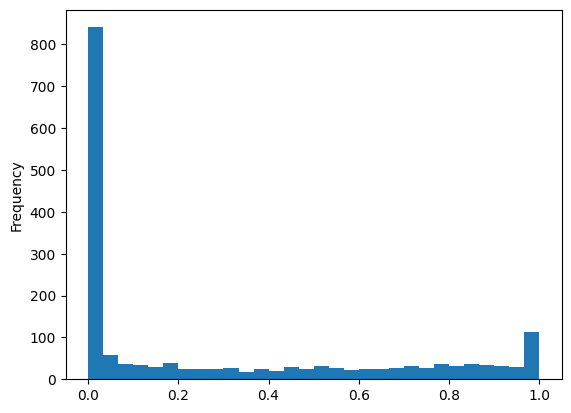

In [8]:
y.plot(kind='hist', bins=30)

<Axes: ylabel='Frequency'>

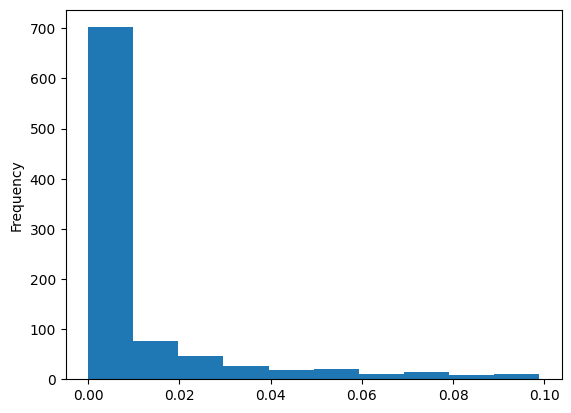

In [10]:
y[y < 0.1].plot(kind="hist")

Separando em treino e teste. 

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

Salvando dados raw

In [39]:
X_train.to_parquet(f"{OUTPUT_DIR}/X_train_raw.parquet", index=False)
X_test.to_parquet(f"{OUTPUT_DIR}/X_test_raw.parquet", index=False)

y_train.to_frame("target").to_parquet(f"{OUTPUT_DIR}/y_train.parquet", index=False)
y_test.to_frame("target").to_parquet(f"{OUTPUT_DIR}/y_test.parquet", index=False)

Salvando dados de treino já normalizados e com OHE

In [40]:
CAT_COL = "SG_UF"

In [41]:
numeric_cols = X_train.drop(columns=[CAT_COL]).select_dtypes(include=["number"]).columns.tolist()

In [42]:
scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index,
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index,
)


In [43]:
ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

X_train_uf_ohe = pd.DataFrame(
    ohe.fit_transform(X_train[[CAT_COL]]),
    columns=ohe.get_feature_names_out([CAT_COL]),
    index=X_train.index,
)

X_test_uf_ohe = pd.DataFrame(
    ohe.transform(X_test[[CAT_COL]]),
    columns=ohe.get_feature_names_out([CAT_COL]),
    index=X_test.index,
)

In [44]:
X_train_scaled_ohe = pd.concat(
    [X_train_num_scaled, X_train_uf_ohe],
    axis=1,
)

X_test_scaled_ohe = pd.concat(
    [X_test_num_scaled, X_test_uf_ohe],
    axis=1,
)

# garante mesma ordem de colunas
X_test_scaled_ohe = X_test_scaled_ohe[X_train_scaled_ohe.columns]

In [45]:
X_train_scaled_ohe.to_parquet(f"{OUTPUT_DIR}/X_train_scaled_ohe.parquet", index=False)
X_test_scaled_ohe.to_parquet(f"{OUTPUT_DIR}/X_test_scaled_ohe.parquet", index=False)

joblib.dump(
    {
        "scaler": scaler,
        "ohe": ohe,
        "numeric_cols": numeric_cols,
        "cat_col": CAT_COL,
        "final_columns": X_train_scaled_ohe.columns.tolist(),
    },
    f"{OUTPUT_DIR}/preprocessor_scaler_ohe.joblib",
)

['../Datasets/Split/preprocessor_scaler_ohe.joblib']

In [46]:
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"X_train_scaled_ohe: {X_train_scaled_ohe.shape}")
print(f"X_test_scaled_ohe: {X_test_scaled_ohe.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (1424, 23)
X_test:  (357, 23)
X_train_scaled_ohe: (1424, 31)
X_test_scaled_ohe: (357, 31)
y_train: (1424,)
y_test:  (357,)
